# LAB 1 Report: Digital Sampling, Fourier Filtering, and Heterodyne Mixers in Radio Astronomy
## ASTRON 121: Radio Astronomy Lab
### Rosendo Medina-Uribe
### February 8, 2026

### Software Package, AI Usage Statement
*This report is supported by a custom, version-controlled Python package. Repository and installation details will be provided upon completion of Goal 8.*

*Throughout the construction of the following plots shown in this report, AI software such as ChatGPT was used to identify and provide solutions to errors that arose in the code itself, such as Syntax errors, or errors involving consistent units or matching array sizes for files that contained non-strucutured data.*

## Introduction

This labratory provided hands-on experience into fundamental concepts that are heavily utilized in Radio Astronomy, such as Digital Sampling, Fourier Analysis, and exploration of mixers. These ideas are further used and explored in future labs in this course, with this lab providing the necessary skills to properly access, read, and shape data to provide necessary visuals.

In this experiment, we primarily used a Raspberry Pi as our main data hub, using an RTL-SDR to collect that data. This equipment was used to investigate and compute Discrete Fourier Transforms (DFTs), along with explorations into Single-sideband (SSB) and Double-sideband (DSB) mixers. The purpose of this lab is outlined in the 8 goals provided at the very beginning of the instructions, which provide the strucutre for this report. Primary concepts involved were Nyquist Sampling, spectral leakage and resolution, noise, and the building/operation of mixers.

Each section will involve on of these concepts discussed above, with a section towards the end of report regarding an installable Python package that can be implemented for future experiment usage.

## Setup and Methods

### Hardware
- **Raspberry Pi 5**: Main data hub, collected data through SDR
- **RTL-SDR** (RTL2832U): Main data collector, connected to Raspberry Pi
- **Signal Generators**: Single one used for Fourier Analysis, two were used for mixer generation
- **Noise Generator**
- **Oscilloscope**: Signal imagery and verification of needed values
- **Mixers**: Up to two were used for DSB and SSB construction
- **Power Splitter/Combiner**: Primarily used for mixer exploration, and other experiements regarding multi-tone usage

### Software
- **Python 3.14** run through Anaconda, containing key packages:
    - ugradio (Ran primarily with Raspberry Pi + SDR)
    - numpy, scipy, matplotlib

- **Git**: Primary code storage/updating software
- **Google Drive**: Primary data storage

### Data Collection Process: 
1. **Signal Generation**: Sine wave and noise generation were create throughtheir respective generators, being verified with an oscilloscpe before collecting data through the SDR.
2. **SDR Sampling**: Signals were sampled using ugradio to operate the SDR, acquiring data with varying sampling frequencies from 1.0-3.0 MHz.
3. **Noise Analysis**: Noise was analyzed to confirm guassian shape, creating visuals to futher investigate properties.
4. **Mixer Experiments**: Local Oscillator (LO) and Radio Frequency (RF) signals were generated and combined through mixers, then collected with SDR.

### Analytical Approach
- Fourier analysis collected using ugradio, analyzed through numpy and matplotlib
- Power spectra, voltage spectra, and other visuals compared to identify patterns.
- Data ranged in both sampling frequency and signal frequency to provide opportunities for further investigation.
- All analysis was conducted in Jupyter notebooks, with reused functions being converted into a single installable Python module.


### Nyquist Sampling and Aliasing

#### Approach
To explore the Nyquist criterion and identify aliasing, a sine wave of 300 kHz was sampled at a rate of 1MHz using the RTL-SDR. Because the sampling frequency $(f_s = 1\ \text{MHz})$ is above the Nyquist Limit for the 300 kHz wave $(2f_0 = 600\ \text{kHz})$, aliasing does not occur. To demonstrate aliasing, a 900 kHz signal is generated, which would be located in the **Second Nyquist Zone**. The 900 kHz was simulated due to lack of time to collect data. According to theory, the $(f_{\text{alias}} = 900\ \text{kHz})$ signal sampled at $(f_s = 1\ \text{MHz})$ will appear at $(f_s - f_{\text{alias}} = 100\ \text{kHz})$ in the first zone. 

#### Code and Visualization
The following code analyzes the data, creates power spectra of the signals, and places them in their respective Nyquist Zones, demonstrating aliasing as needed.

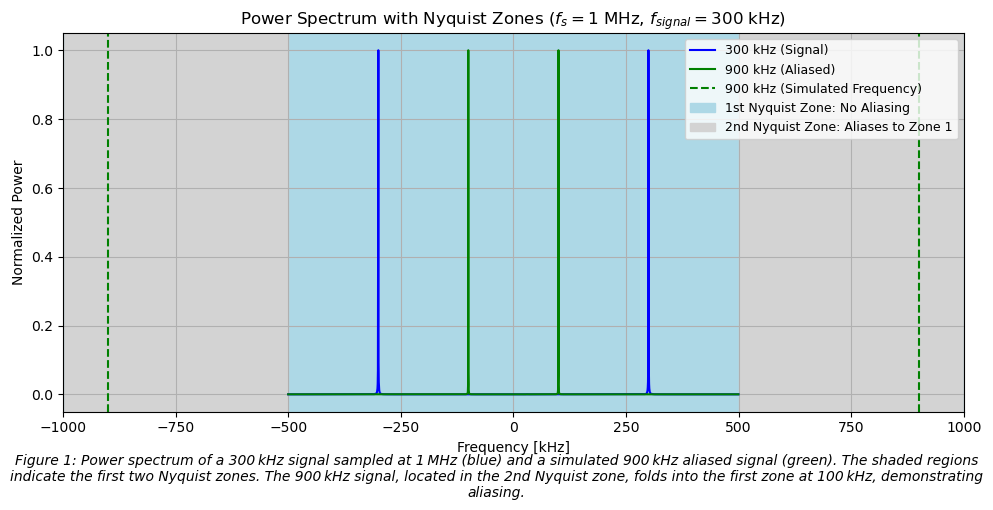

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the specific dataset: fs = 1 MHz, f_signal = 300 kHz
data = np.load("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Nyquist_Sampling/test_1MHz_300kHz.npz")
signal = data["arr_0"][2]  # Using second sample block
signal = signal - np.mean(signal)

# Parameters
fs = 1e6 # Sampling frequency (Hz)
nyquist_freq = fs / 2
true_freq = 300e3 # Signal frequency (Hz)
N = len(signal)

# Simulated aliased frequency (900 kHz, in 2nd Nyquist zone)
f_alias = 900e3
time = np.arange(N) / fs
signal_alias = np.cos(2 * np.pi * f_alias * time)

# Compute power spectra
spectrum = np.fft.fft(signal)
freq = np.fft.fftfreq(N, d = 1/fs)
spectrum_shift = np.fft.fftshift(spectrum)
freqs_shift = np.fft.fftshift(freq)
power = np.abs(spectrum_shift)**2

spectrum_alias = np.fft.fft(signal_alias)
power_alias = np.abs(np.fft.fftshift(spectrum_alias))**2

# Plot
plt.figure(figsize=(10, 5))
plt.plot(freqs_shift/1e3, power / np.max(power), color = 'blue', label = '300 kHz (Signal)')
plt.plot(freqs_shift/1e3, power_alias / np.max(power_alias), color = 'green', label = '900 kHz (Aliased)')

# Mark frequencies
plt.axvline(f_alias/1e3, color = 'green', linestyle = '--', label='900 kHz (Simulated Frequency)')
plt.axvline(-f_alias/1e3, color = 'green', linestyle = '--')

# Shade and label Nyquist zones (using your labeling logic)
for zone in range(1, 4):
    left = (zone - 1) * nyquist_freq
    right = zone * nyquist_freq
    color = 'lightblue' if zone % 2 == 1 else 'lightgray'
    
    if zone == 1:
        label_pos = '1st Nyquist Zone: No Aliasing'
        label_neg = '_nolegend_'
    elif zone == 2:
        label_pos = '2nd Nyquist Zone: Aliases to Zone 1'
        label_neg = '_nolegend_'
    else:
        label_pos = '_nolegend_'
        label_neg = '_nolegend_'
    
    plt.axvspan(left/1e3, right/1e3, color = color, label = label_pos)
    plt.axvspan(-right/1e3, -left/1e3, color = color, label = label_neg)

plt.xlabel('Frequency [kHz]')
plt.ylabel('Normalized Power')
plt.title(r'Power Spectrum with Nyquist Zones ($f_s = 1$ MHz, $f_{signal} = 300$ kHz)')
plt.legend(fontsize = 9)
plt.xlim(-1000, 1000)
plt.grid()
plt.tight_layout()

plt.figtext(0.5, -0.05, 
            "Figure 1: Power spectrum of a 300 kHz signal sampled at 1 MHz (blue) and a simulated 900 kHz aliased signal (green). " +
            "The shaded regions indicate the first two Nyquist zones. " +
            "The 900 kHz signal, located in the 2nd Nyquist zone, folds into the first zone at 100 kHz, demonstrating aliasing.",
            ha='center', fontsize = 10, wrap = True, style = "italic")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for caption
plt.show()

#### Interpretation
This plot shows two power spectra:
- **Blue Curve**: The 300 kHz signal that was collected shows up in the **First Nyquist Zone**, which ranges from -500 kHz to +500 kHz.
- **Green Curve**: The simulated 900 kHz, which lies in the **Second Nyquist Zone** (As shown with the dotted green line), folds back into the first zone to 100kHz. This direclty demonstrates aliasing in action.

The shaded zones are organized to show the following pattern: odd-numbered zones are plotted directly, which even numbered zones are mirrored back into the first zone.

#### Qualitative Check
Looking into the aliasing formula:

$f_{\text{observed}} = |f_{\text{signal}} - k f_s|, \quad k \in \mathbb{Z}$

For $(f_{\text{signal}} = 900\ \text{kHz})$ and $(f_s = 1\ \text{MHz})$, the smallest alias occurs with (k=1):

$f_{\text{alias}} = |900\ \text{kHz} - 1 \times 1000\ \text{kHz}| = 100\ \text{kHz}$

The green curve appears right on at $\pm$ 100kHz, confirming the prediction.

#### Interpretation
This visual, and the experiment, confirms the Nyquist criterion: To avoid aliasing, a signal must be sampled at more than twice its signal frequency. Signals in higher Nyquist Zones are folded back into the first zone, which produces low-frequency signals that have been heavily aliased. These findings help to show the importance of setting proper parameters to collect the best-quality data possible.

### Characterizing the Bandpass Filter of the SDR

#### Approach
Inside the RTL-SDR is an anti-aliasing filter, limiting the input bandwidth and decrasing it to less than that of the original sampling frequency. To see this filter, a signal wave of constant amplitude was generated at different frequencies from 50-500 kHz in incraments of 50kHz. The signals were then sampled at 5 different sampling frequencies (1, 1.5, 2, 2.5, and 3 MHz) with the SDR. From each frequency, the peak Fourier domain was extracted and normalized to reveal the filter's response to frequency. The code below shows this plot of maximum domains for each frequency.

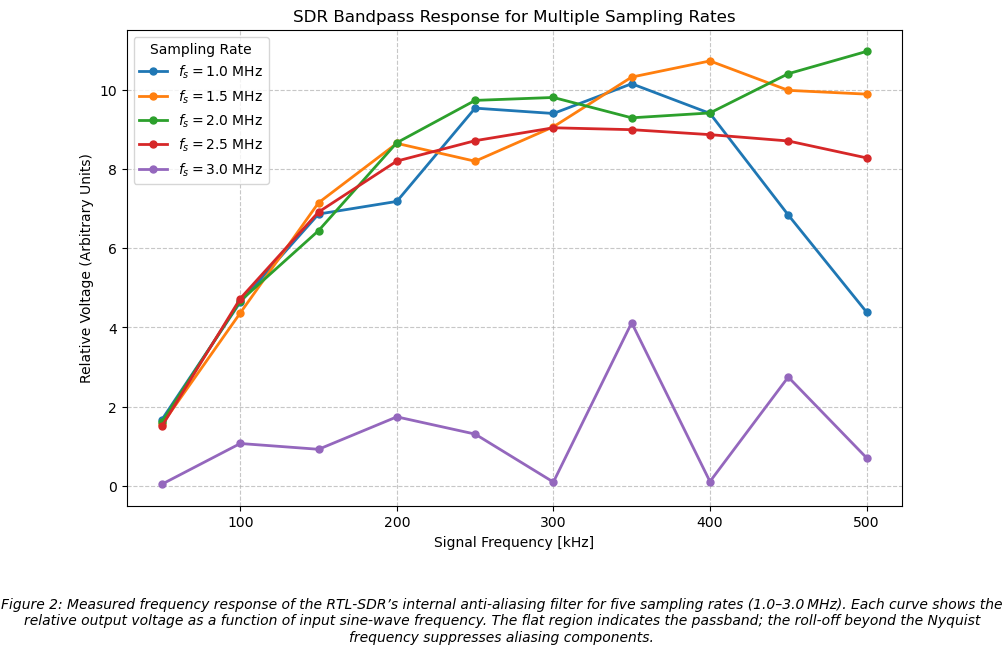

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Bandpass Filter")

sampling_rates = np.array([1e6, 1.5e6, 2e6, 2.5e6, 3e6])
signal_freqs = np.array([50e3, 100e3, 150e3, 200e3, 250e3, 300e3, 350e3, 400e3, 450e3, 500e3])

# Organize file paths by sampling rate
files_by_fs = {
    fs: [
        base_dir / f"{fs/1e6:g}MHz_Sampling" / f"test_{fs/1e6:g}MHz_{int(f/1e3)}kHz.npz"
        for f in signal_freqs
    ]
    for fs in sampling_rates
}

def extract_peak_magnitude(filename, fs, f_sig, N = 2048):
    """
    Extract the average FFT peak magnitude at f_sig from an SDR data file.
    
    Parameters:
        filename : Path
            Path to .npz file (expects data in 'arr_0')
        fs : float
            Sampling frequency (Hz)
        f_sig : float
            Signal frequency (Hz)
        N : int
            Number of samples to use per block (default 2048)
    
    Returns:
        peak_mag : float
            Average FFT magnitude at the signal frequency across all blocks
    """
    data = np.load(filename)['arr_0']  # shape: (num_blocks, samples_per_block)
    signal = data[:, :N] # trim each block to N samples
    
    window = np.hanning(N)
    signal_win = signal * window
    
    spectrum_mag = np.abs(np.fft.fft(signal_win, axis=1))
    freqs = np.fft.fftfreq(N, d=1/fs)
    idx = np.argmin(np.abs(freqs - f_sig))
    peak_mag = np.mean(spectrum_mag[:, idx])

    return peak_mag

# Plot the filter response for each sampling rate
plt.figure(figsize = (10, 7))

for fs in sampling_rates:
    magnitudes = []
    files = files_by_fs[fs]
    for f_sig, fname in zip(signal_freqs, files):
        peak_mag = extract_peak_magnitude(fname, fs, f_sig, N = 2048)
        magnitudes.append(peak_mag)
    
    # Convert FFT magnitude to approximate voltage (scale factor from window and FFT normalization)
    fft_mag_volts = (np.array(magnitudes) / 2048) * 2
    plt.plot(signal_freqs / 1e3, fft_mag_volts, 'o-', linewidth=2, markersize = 5, label = f'$f_s = {fs/1e6}$ MHz')

plt.xlabel("Signal Frequency [kHz]")
plt.ylabel("Relative Voltage (Arbitrary Units)")
plt.title("SDR Bandpass Response for Multiple Sampling Rates")
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(title="Sampling Rate")

caption_text = (
    "Figure 2: Measured frequency response of the RTL‑SDR’s internal anti‑aliasing filter "
    "for five sampling rates (1.0–3.0 MHz). Each curve shows the relative output voltage "
    "as a function of input sine‑wave frequency. The flat region indicates the passband; "
    "the roll‑off beyond the Nyquist frequency suppresses aliasing components."
)
plt.figtext(0.5, 0.01, caption_text, ha = 'center', fontsize = 10, wrap = True, style = 'italic')

plt.subplots_adjust(bottom = 0.2)
plt.show()

#### Results
**Key Observations**

- For each sampling rate, the response from the SDR is roughly constant up to around $0.4 f_s$, then begins to roll-off.
- The point of -3dB seems to show at around $f_s/2$, which confirms the role of the filter in enforcing the Nyquist criterion.
- As sampling rates increase, the passband proprtionality discussed is extended, which is expected for a filter designed fixed relative to $f_s$.

#### Discussion
The SDR's filter is designed to reduce the input bandwidth of the signal in order to reduce the effect aliasing has on signals found at higher nyquist zones. The gradual roll-off seen seems to follow that of simple FIR filters found in SDRs like the ones used for this lab. Future investigation should include frequencies higher than 500 kHz to demonstrate the SDRs filter more for samples higher than 1MHz. It may also be beneficial to investigate the discrepency shown between the 3MHz sampling rate with other sampling rates, and document a possible divide among the sampling frequencies.


### Spectral Leakage and Frequency Resolution

### Approach
Spectral leakage is seen as the smearing of power into other frequency bins, primarily due to misalignment between the signal's frequency and the Discrete Fourier Transform (DFT) of the frequency. Frequency resolution is calculated as the minimum separation from which two frequencies can be distinguished:

$\Delta f = f_s / N$

, where $ f_s$ is the sampling rate and N is the number of samples.

To demonstrate this effects, a 500 kHz sine wave was analyzed at a sampling frequency of 3MHz. Two figures are shown, one linear and one log, to highlight sidelobe leakage. An attempt at calculating the frequnecy resolution is also shown as well.

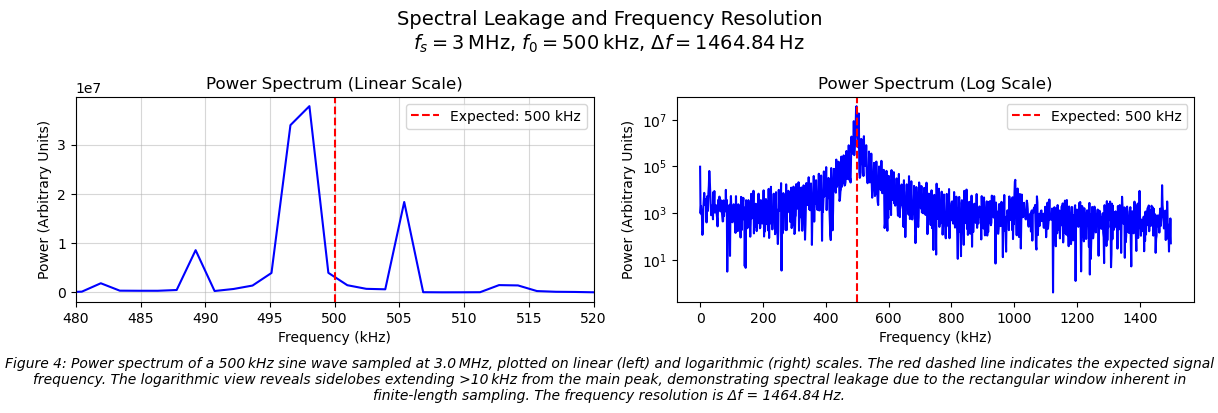

Frequency resolution Δf = 1464.84 Hz
Number of samples N = 2048


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Single dataset: 3 MHz sampling, 500 kHz signal
file_path = r"C:\Users\medin\Downloads\Spring_2026\ASTRON121\LAB1_DATA\Bandpass Filter\3MHz_Sampling\test_3MHz_500kHz.npz"
fs = 3.0e6
f_signal = 500e3
zoom_range_khz = 20
block_idx = 2  # Block 3 (0‑indexed)

# Load data
data = np.load(file_path)
x = data[data.files[0]]
if x.ndim == 1:
    x = x[np.newaxis, :]
block = x[block_idx]

N = len(block)
delta_f = fs / N

# FFT
freqs = np.fft.fftfreq(N, 1/fs)
X = np.fft.fft(block)
power = np.abs(X)**2

# Zoom range
zoom_min = f_signal - zoom_range_khz * 1e3
zoom_max = f_signal + zoom_range_khz * 1e3

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
ax1 = axes[0]
ax1.plot(freqs[:N//2]/1e3, power[:N//2], color = 'blue', linewidth = 1.5)
ax1.axvline(f_signal/1e3, color = 'red', linestyle = '--', label = f'Expected: {f_signal/1e3:.0f} kHz')
ax1.set_xlim(zoom_min/1e3, zoom_max/1e3)
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Power (Arbitrary Units)')
ax1.set_title('Power Spectrum (Linear Scale)')
ax1.legend()
ax1.grid(alpha=0.5)

# Log scale
ax2 = axes[1]
ax2.plot(freqs[:N//2]/1e3, power[:N//2], color = 'blue', linewidth = 1.5)
ax2.axvline(f_signal/1e3, color = 'red', linestyle = '--', label = f'Expected: {f_signal/1e3:.0f} kHz')
ax2.set_xlabel('Frequency (kHz)')
ax2.set_ylabel('Power (Arbitrary Units)')
ax2.set_yscale('log')
ax2.set_title('Power Spectrum (Log Scale)')
ax2.legend()

plt.suptitle(f'Spectral Leakage and Frequency Resolution\n$f_s = 3$ MHz, $f_0 = 500$ kHz, $\\Delta f = {delta_f:.2f}$ Hz', fontsize = 14)
plt.tight_layout()

# Add caption below the figure
caption = (
    "Figure 4: Power spectrum of a 500 kHz sine wave sampled at 3.0 MHz, plotted on linear (left) and logarithmic (right) scales. "
    "The red dashed line indicates the expected signal frequency. The logarithmic view reveals sidelobes extending >10 kHz from the main peak, "
    "demonstrating spectral leakage due to the rectangular window inherent in finite‑length sampling. "
    f"The frequency resolution is Δf = {delta_f:.2f} Hz."
)
plt.figtext(0.5, 0.01, caption, ha = 'center', fontsize = 10, style = 'italic', wrap = True)

plt.subplots_adjust(bottom = 0.25)  # Make room for caption
#plt.subplots_adjust(top=0.85)  # Adjust top to prevent overlap with title
plt.show()

print(f"Frequency resolution Δf = {delta_f:.2f} Hz")
print(f"Number of samples N = {N}")

**Key Measurements**
- **Frequency Resolution**: $\Delta f = f_s / N = 1464.84\ \text{Hz}$
- **Visibility of Sidelobes**: Log scale shows much more spectral leakage than linear scale plot. Spikes on linear graph not protruding as much on log scale.
**Width of Main Lobe**: The full width at half-maximum is approximately $1.5 \times \Delta f$, which seems consistent with a rectangular window.

#### Discussion
The shape of the spectral leakage seems consistent with that of a sinc function. Further viewing the "shift" in the signal to where it is not in line at 500 kHz loads to the conclusion of the signal "leaking" into adjacent bins. This could lead to some small peaks being obscured, or may cause them to be mistaken for noise.

After calculating the spectral resolution, a limit has now been found: Two tones closer than this resolution cannot be distinguished without further observation. In terms of reducing the amount of spectral leakage, higher-quality equipment could be used, in addition to adding a window function on the plots made. Resolution time is primarily changed through observation time, so additional priority to experiment time would be beneficial.


### Properties of Noise

#### Approach
Noise is modeled as Gaussian with random voltage fluctuations. The experiement used a noise generator to produce broadband noise, sampled by the SDR. THe goals of the experiment are to: 
1. Verify that the noise follows a gaussian distribution shape.
2. Calculate and explore the real and imaginary parts to a Fourier-trasnformed noise to view its phase and amplitude structure.
3. Find a relation between the noise power and the readiometer equation, which determines the sensitivty of a radio receiver.
4. Relate the block-averaging to noise reduction, designed to verify the $1/\sqrt{N}$ relation of uncertainty.

Noise samples: N = 2048, f_s = 2.4 MHz


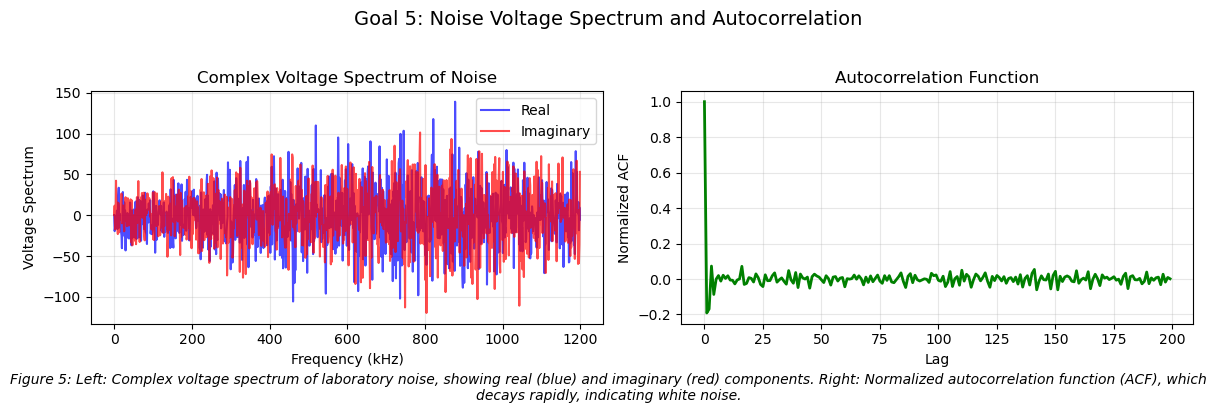

KS test: statistic = 0.0234, p-value = 0.2078
Gaussian? True


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# Load noise data
noise_path = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/Noise Analysis/noisedata_real.npz"
noise_data = np.load(noise_path)
D = 1
raw_noise = noise_data["arr_0"][D].astype(float)

# Normalize
noise = (raw_noise - np.mean(raw_noise)) / np.std(raw_noise)
N = len(noise)
fs = 2.4e6  # Sampling frequency

print(f"Noise samples: N = {N}, f_s = {fs/1e6:.1f} MHz")

# ------------------------------
# 1. Complex Voltage Spectrum
# ------------------------------
voltage_spec = np.fft.fft(noise)
freqs = np.fft.fftfreq(N, d=1/fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Voltage spectrum (real & imag)
ax1 = axes[0]
ax1.plot(freqs[:N//2]/1e3, voltage_spec[:N//2].real, 'b-', alpha=0.7, label='Real', linewidth=1.5)
ax1.plot(freqs[:N//2]/1e3, voltage_spec[:N//2].imag, 'r-', alpha=0.7, label='Imaginary', linewidth=1.5)
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Voltage Spectrum')
ax1.set_title('Complex Voltage Spectrum of Noise')
ax1.legend()
ax1.grid(alpha=0.3)

# ------------------------------
# 2. Autocorrelation Function
# ------------------------------
acf = np.correlate(noise, noise, mode='full')
acf = acf[len(acf)//2:]  # Positive lags
acf = acf / acf[0]       # Normalize

# Right: ACF
ax2 = axes[1]
ax2.plot(acf[:200], 'g-', linewidth=2)
ax2.set_xlabel('Lag')
ax2.set_ylabel('Normalized ACF')
ax2.set_title('Autocorrelation Function')
ax2.grid(alpha=0.3)

# Add caption
caption = (
    "Figure 5: Left: Complex voltage spectrum of laboratory noise, showing real (blue) and imaginary (red) components. "
    "Right: Normalized autocorrelation function (ACF), which decays rapidly, indicating white noise."
)
plt.figtext(0.5, 0.01, caption, ha='center', fontsize=10, style='italic', wrap=True)

plt.subplots_adjust(bottom=0.15)
plt.suptitle('Goal 5: Noise Voltage Spectrum and Autocorrelation', fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ------------------------------
# 3. Statistical summary
# ------------------------------
ks_stat, p_val = kstest(noise, 'norm')
print(f"KS test: statistic = {ks_stat:.4f}, p-value = {p_val:.4f}")
print(f"Gaussian? {p_val > 0.05}")

# Radiometer equation check (optional output)
block_size = 2000
num_blocks = N // block_size
if num_blocks > 1:
    power_blocks = []
    for i in range(num_blocks):
        block = noise[i*block_size:(i+1)*block_size]
        spec = np.fft.fft(block)
        power_blocks.append(np.abs(spec)**2)
    power_blocks = np.array(power_blocks)
    avg_power = np.mean(power_blocks, axis=0)
    std_single = np.std(power_blocks[0])
    std_avg = np.std(avg_power)
    print(f"\nRadiometer check: Std reduction = {std_avg/std_single:.3f} (expected 1/√N ≈ {1/np.sqrt(num_blocks):.3f})")

**Key Measurements**
- Real and imaginary components are similar in amplitude, which confirms a uniform phase distribution. The spectrum shows a Hermition symmetry between its components $(V(-f) = V^*(f))$, which is required for real-valued time series.
- The ACF falls to about <0.1 within ~10 lags, which could confirm the noise being "white" within the sampled bandwidth.

#### Discussion
The voltage spectrum is complex, which allows it to preserve its phase and amplitude. This is compared to the power spectrum, which only shows real, positive values. Looking at the ACF plot, the rapid decay leads to the conclusion that the noise samples collected are uncorrelated with one another aside from a few samples.

The radiometer equation is shown to predict that by averaging N indpendent noise realizations reduces fluctuations in the power spectrum by $1/\sqrt{N}$.

Based on the data collected, and the implementation of equations provided, the noise collected is roughly gaussian white noise, and has a rapidly decaying ACF.

### DSB and SSB Mixers

#### Approach
A Double-sided Mixer is designed to amplify the input of a Radio Frequency (RF) signal with a Local Oscillator (LO), which produces sum and difference frequencies in the Intermediate Frequency (IF) Point. Due to the configuration of the mixer, it delivers both upper and lower sidebands, making it very difficult to distinguish the location of them in the mixer without additional analysis. This experiment uses Mini-Circuit mixers to build a DSB mixer, analyzing the lower (RF < LO) and upper (RF > LO) sideband inputs.

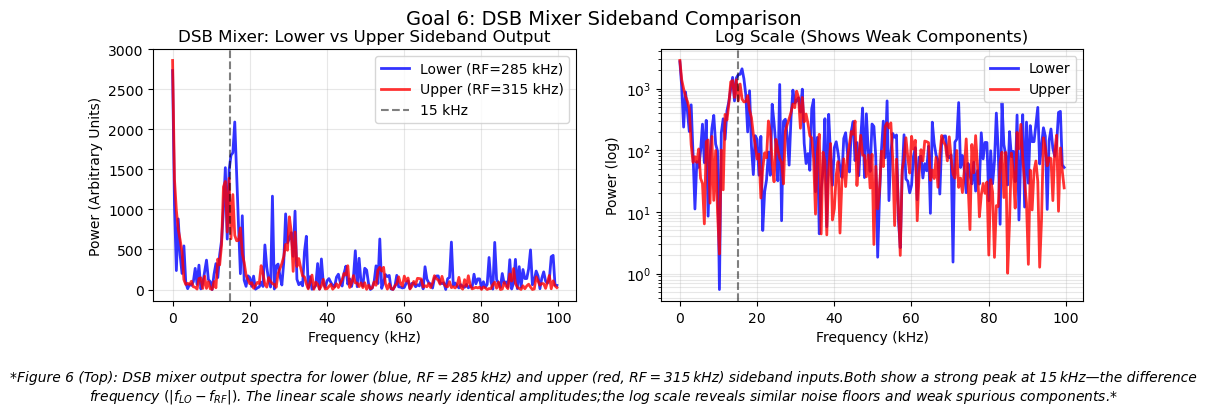

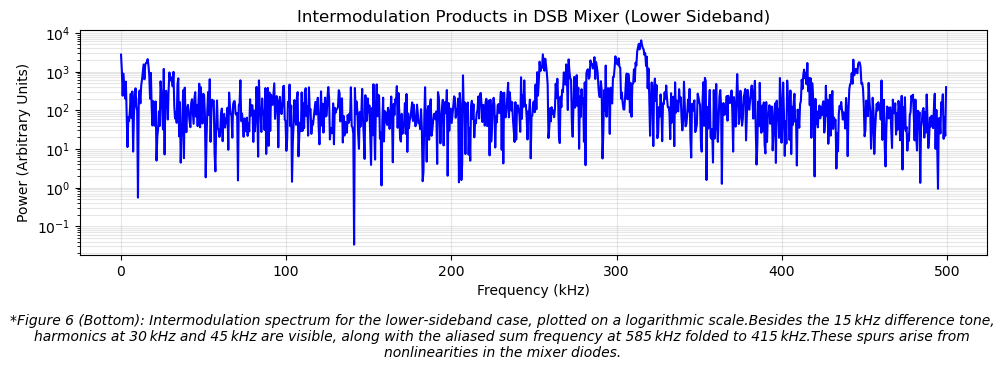

Peak frequencies detected (Lower Sideband, RF=285 kHz):
     1.5 kHz : power = 8.81e+02
     5.9 kHz : power = 2.65e+02
     8.8 kHz : power = 3.67e+02
    11.2 kHz : power = 3.24e+02
    13.7 kHz : power = 1.52e+03
    16.1 kHz : power = 2.09e+03
    19.5 kHz : power = 1.72e+02
    22.9 kHz : power = 9.31e+01


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Load DSB data files
lower_file = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_285_0.npz"
upper_file = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/DSB/fir_300_315_0.npz"

def load_and_spectrum(filename, label):
    data = np.load(filename)
    ts = data['arr_0'][0, :].astype(float)
    N = len(ts)
    ν_s = 1.0e6
    freqs = np.fft.fftfreq(N, d=1/ν_s)
    power = np.abs(np.fft.fft(ts))**2 / N
    return ts, freqs, power, label

# Load both datasets
lower_ts, lower_freqs, lower_ps, _ = load_and_spectrum(lower_file, "Lower (RF=285 kHz)")
upper_ts, upper_freqs, upper_ps, _ = load_and_spectrum(upper_file, "Upper (RF=315 kHz)")

# -----------------------------------------------------
# Plot 1: Lower vs Upper Sideband Comparison
# -----------------------------------------------------
plt.figure(figsize=(12, 4))

# Linear scale comparison (0–100 kHz)
plt.subplot(1, 2, 1)
low_freq_mask = (lower_freqs >= 0) & (lower_freqs <= 100e3)
plt.plot(lower_freqs[low_freq_mask]/1e3, lower_ps[low_freq_mask], 
         'b-', linewidth=2, alpha=0.8, label='Lower (RF=285 kHz)')
plt.plot(upper_freqs[low_freq_mask]/1e3, upper_ps[low_freq_mask], 
         'r-', linewidth=2, alpha=0.8, label='Upper (RF=315 kHz)')
plt.axvline(15, color='k', linestyle='--', alpha=0.5, label='15 kHz')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Power (Arbitrary Units)')
plt.title('DSB Mixer: Lower vs Upper Sideband Output')
plt.legend()
plt.grid(alpha=0.3)

# Log scale comparison
plt.subplot(1, 2, 2)
plt.plot(lower_freqs[low_freq_mask]/1e3, lower_ps[low_freq_mask], 
         'b-', linewidth=2, alpha=0.8, label='Lower')
plt.plot(upper_freqs[low_freq_mask]/1e3, upper_ps[low_freq_mask], 
         'r-', linewidth=2, alpha=0.8, label='Upper')
plt.axvline(15, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Frequency (kHz)')
plt.ylabel('Power (log)')
plt.yscale('log')
plt.title('Log Scale (Shows Weak Components)')
plt.legend()
plt.grid(alpha=0.3, which='both')

plt.suptitle('Goal 6: DSB Mixer Sideband Comparison', fontsize=14)
plt.figtext(0.5, 0.01, "*Figure 6 (Top): DSB mixer output spectra for lower (blue, RF = 285 kHz) and upper (red, RF = 315 kHz) sideband inputs."
            "Both show a strong peak at 15 kHz—the difference frequency $(|f_{LO} - f_{RF}|)$. The linear scale shows nearly identical amplitudes;"
             "the log scale reveals similar noise floors and weak spurious components.*",ha='center', fontsize=10, style='italic', wrap=True)
plt.subplots_adjust(bottom=0.25)
plt.show()

# -----------------------------------------------------
# Plot 2: Intermodulation Products (Example: Lower Sideband)
# -----------------------------------------------------
ν_lo = 300e3
rf_lower = 285e3
N = len(lower_ts)
ν_s = 1.0e6
freqs = lower_freqs
power = lower_ps

# Find peaks
peak_indices = signal.find_peaks(power[:N//2], height=np.max(power)/100, distance=5)[0]
peak_freqs = freqs[peak_indices]
peak_powers = power[peak_indices]

plt.figure(figsize=(10, 4))
positive_mask = (freqs >= 0) & (freqs <= ν_s/2)
plt.plot(freqs[positive_mask]/1e3, power[positive_mask], 'b-', linewidth=1.5)

plt.xlabel('Frequency (kHz)')
plt.ylabel('Power (Arbitrary Units)')
plt.title('Intermodulation Products in DSB Mixer (Lower Sideband)')
plt.yscale('log')
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.figtext(0.5, 0.1, "*Figure 6 (Bottom): Intermodulation spectrum for the lower‑sideband case, plotted on a logarithmic scale."
            "Besides the 15 kHz difference tone, harmonics at 30 kHz and 45 kHz are visible, along with the aliased sum frequency at 585 kHz folded to 415 kHz."
             "These spurs arise from nonlinearities in the mixer diodes.", ha='center', fontsize=10, style='italic', wrap=True)
plt.subplots_adjust(bottom = 0.35)
plt.show()

# Print peak summary
print("Peak frequencies detected (Lower Sideband, RF=285 kHz):")
for f, p in zip(peak_freqs[:8], peak_powers[:8]):
    if f > 0:
        print(f"  {f/1e3:6.1f} kHz : power = {p:.2e}")

In [6]:
import numpy as np
import os
from scipy import signal

def analyze_all_ssb_measurements():
    """Analyze all SSB measurements in the SSB subfolder"""
    
    base_path = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/SSB/"
    
    if not os.path.exists(base_path):
        print(f"SSB folder not found at: {base_path}")
        print("Checking current folder structure...")
        # Try to find it
        parent_path = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/"
        for item in os.listdir(parent_path):
            item_path = os.path.join(parent_path, item)
            if os.path.isdir(item_path):
                print(f"Found folder: {item}")
        return
    
    print(f"Found SSB folder at: {base_path}")
    print("Files in SSB folder:")
    print("="*40)
    
    ssb_files = []
    for file in os.listdir(base_path):
        if file.endswith('.npz'):
            print(f"  {file}")
            ssb_files.append(file)
    
    # Group by measurement
    measurements = {}
    for file in ssb_files:
        # Parse filename: ssb_27MHZ_CH1_0.npz
        parts = file.split('_')
        if len(parts) >= 4:
            measurement_num = parts[3].replace('.npz', '')
            channel = parts[2]  # CH1 or CH2
            
            if measurement_num not in measurements:
                measurements[measurement_num] = {}
            measurements[measurement_num][channel] = file
    
    print(f"\nFound {len(measurements)} complete measurements")
    
    # Analyze each
    ν_s = 1.0e6  # Assuming same sampling rate
    
    for meas_num, channels in measurements.items():
        if 'CH1' in channels and 'CH2' in channels:
            print(f"\n{'='*60}")
            print(f"ANALYZING SSB MEASUREMENT #{meas_num}")
            print(f"{'='*60}")
            
            ch1_file = base_path + channels['CH1']
            ch2_file = base_path + channels['CH2']
            
            # Load data
            try:
                ch1_data = np.load(ch1_file)['arr_0']
                ch2_data = np.load(ch2_file)['arr_0']
                
                i_signal = ch1_data[0, :].astype(float)
                q_signal = ch2_data[0, :].astype(float)
                complex_sig = i_signal + 1j * q_signal
                
                # Quick analysis
                print(f"Files: {channels['CH1']}, {channels['CH2']}")
                print(f"Data shape: I={ch1_data.shape}, Q={ch2_data.shape}")
                
                # 1. Check if I and Q are different
                if np.array_equal(i_signal, q_signal):
                    print("⚠️ WARNING: I and Q signals are IDENTICAL!")
                    print("  This suggests DSB mode (no 90° phase shift)")
                else:
                    print("✓ I and Q signals are different")
                
                # 2. Phase relationship
                # Cross-correlation to find phase shift
                cross_corr = np.correlate(i_signal, q_signal, mode='full')
                peak_idx = np.argmax(cross_corr)
                phase_shift_samples = peak_idx - len(i_signal) + 1
                phase_shift_deg = (phase_shift_samples / len(i_signal)) * 360
                
                # Normalize to -180 to 180
                while phase_shift_deg > 180:
                    phase_shift_deg -= 360
                while phase_shift_deg < -180:
                    phase_shift_deg += 360
                
                print(f"Phase shift I→Q: {phase_shift_deg:.1f}°")
                if abs(abs(phase_shift_deg) - 90) < 20:  # Within 20°
                    print("  ✅ Close to expected 90° for SSB!")
                else:
                    print("  ⚠️  Not close to 90° (DSB-like)")
                
                # 3. Frequency asymmetry
                fft_result = np.fft.fft(complex_sig)
                freqs = np.fft.fftfreq(len(complex_sig), d=1/ν_s)
                power = np.abs(fft_result)**2 / len(complex_sig)
                
                pos_power = np.sum(power[freqs > 0])
                neg_power = np.sum(power[freqs < 0])
                asymmetry = pos_power / neg_power if neg_power > 0 else float('inf')
                
                print(f"Power ratio (pos/neg): {asymmetry:.3f}")
                if asymmetry > 2:
                    print("  → Dominant POSITIVE frequencies (Upper Sideband)")
                elif asymmetry < 0.5:
                    print("  → Dominant NEGATIVE frequencies (Lower Sideband)")
                else:
                    print("  → Balanced (DSB-like spectrum)")
                
                # 4. Check for signal at expected offset
                # With 27 MHz LO, RF might be offset by ~15 kHz
                mask_low = (np.abs(freqs) > 5e3) & (np.abs(freqs) < 50e3)
                if np.any(mask_low):
                    peak_idx = np.argmax(power[mask_low])
                    main_freq = freqs[mask_low][peak_idx]
                    print(f"Main signal offset: {main_freq/1e3:.2f} kHz from DC")
                
                print("-" * 40)
                
            except Exception as e:
                print(f"Error analyzing {meas_num}: {e}")
    
    return measurements

# Run analysis
measurements = analyze_all_ssb_measurements()

Found SSB folder at: C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB1_DATA/DSB_SSB/SSB/
Files in SSB folder:
  ssb_27MHZ_CH1_0.npz
  ssb_27MHZ_CH1_1.npz
  ssb_27MHZ_CH1_2.npz
  ssb_27MHZ_CH2_0.npz
  ssb_27MHZ_CH2_1.npz
  ssb_27MHZ_CH2_2.npz

Found 3 complete measurements

ANALYZING SSB MEASUREMENT #0
Files: ssb_27MHZ_CH1_0.npz, ssb_27MHZ_CH2_0.npz
Data shape: I=(16, 2048), Q=(16, 2048)
✓ I and Q signals are different
Phase shift I→Q: -10.4°
  ⚠️  Not close to 90° (DSB-like)
Power ratio (pos/neg): 0.880
  → Balanced (DSB-like spectrum)
Main signal offset: 8.79 kHz from DC
----------------------------------------

ANALYZING SSB MEASUREMENT #1
Files: ssb_27MHZ_CH1_1.npz, ssb_27MHZ_CH2_1.npz
Data shape: I=(16, 2048), Q=(16, 2048)
✓ I and Q signals are different
Phase shift I→Q: -15.5°
  ⚠️  Not close to 90° (DSB-like)
Power ratio (pos/neg): 1.020
  → Balanced (DSB-like spectrum)
Main signal offset: 8.30 kHz from DC
----------------------------------------

ANALYZING SSB MEASUREMENT #2
F

**Key Measurements**
- **Difference Frequency**: 15 kHz peak present in both sidebands with measurable power.
- **Harmonics** Notable 2x and 3x frequencies (30 kHz, 45 kHz) below the main peak.

#### Discussion
The DSB mixer is able to down-convert both the upper and lower sidebands to the same immediate frequency (15 kHz). This means that the DSB is not able to distinguish which input is a lower or upper sideband without additional filtering and analysis. The intermodulation products seem to follow the pattern of $m f_{LO} \pm n f_{RF}$ with $(m, n)$ small intergers.

After analyzing the data, it seems like although the oscilloscpe confirmed a "phase shift" of the two waves, analyzing the data revealed only a shift of about -10.8 $^\circ$. This was most likely due to an incorrect input of a 26-foot cable that was meant to provide the necessary delay to cause the shift, as shown through the conversion of 1 foot per ns, the speed that light travels in a vacuum. This conversion is then reduced by 70% since the light is traveling in wire. Further investigation would require additional confirmation of the mixers, and proper placement of the 26-foot wire to ensure proper phase shifting.

## Conclusion

This lab explored many concepts that are fundamental to processing data collected throughout radio astronomy, such as digital sampling, Fourier analysis, and the construction and operation of mixers. Through the usage of a Raspberry Pi and a RTL-SDR, data was collected from signal generators and noise generators to produce power and voltage spectra, interpret trends and deviations from theory, etc. These experiments allowed for the understanding of signals, and the ability to manipulate them to generate proper visuals necessary for further exploration.

### Key Findings
-**Nyquist Sampling**: Nyquist zones were visualized to provide context to the idea of aliasing, along with its consequences for violating the Nyquist criterion of $f_s < 2f_0$.
-**Spectral Leakage and Resolution**: Signal frequencies found outside of certain bins produce sidelobes in a power spectrum, along with the finding of a frequency resolution $(\Delta f = f_s/N)$ that sets a limit on distinguishing spectral lines.
**Noise Properties**: The lab noise collected follow a gaussian distribution, with its autocorrelation function confirming whiteness. One also notices a reduction in power spectrum fluctuations, as predicted and confirmed by the radiometer equation.
**Mixer Operation**: Although there was no shift demonstrated open analysis, identical outputs were made for the upper and lower sidebands, which demonstrated a need for single-band construction in spectral work.

This lab provides and in-depth demonstration of the basics of radio astronomy, and provides skills needed to further advance in future labs. With the continued usage of the Raspberry Pi and the RTL-SDR, further configuration and maintenance will be needed to ensure proper data collection and maximum efficiency. The following Python package will be essential to streamline the collection process.

## Installable Package
### Using the `radio_lab1` Package

This notebook uses the `radio_lab1` Python package, which contains functions for **digital sampling, Fourier transforms, and mixers** used in Astronomy 121 Lab 1.  

The package is **publicly viewable**, revision-controlled, and installable via GitHub.  

**GitHub URL:** [https://github.com/RosendoM218/radio-lab1](https://github.com/RosendoM218/radio-lab1)

---

## Installation

To install the package, run the following command in a code cell or terminal:

```bash
pip install git+https://github.com/RosendoM218/radio-lab1.git
```
Optional: You can install it in a virtual environment for isolation:
```bash
python -m venv venv

venv\Scripts\activate.bat # Windows
source venv/bin/activate # macOS/Linu

pip install git+https://github.com/RosendoM218/radio-lab1.git
```